# Sprint 13 — Projeto: Análise de Rotatividade — Model Fitness

Análise completa de rotatividade de clientes de academia, incluindo EDA, modelos preditivos e agrupamentos.

## Passo 1. Carregamento dos Dados

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

# Carrega o dataset
df = pd.read_csv('gym_churn_us.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (4000, 14)


,gender,Near_Location,Partner,Promo_friends,Phone,Age,Lifetime,Contract_period,Month_to_end_contract,Group_visits,Avg_class_frequency_total,Avg_class_frequency_current_month,Avg_additional_charges_total,Churn
0,0,1,1,0,1,22,0,3,1,1,2.05,1.99,47.77,0
1,1,1,0,0,1,39,3,6,1,1,1.39,1.24,131.83,0
2,0,0,1,0,1,39,5,3,3,0,1.94,1.47,24.63,0
3,0,1,1,0,1,27,1,6,3,1,1.04,1.22,4.34,0
4,0,1,0,0,1,26,4,1,0,1,0.21,0.17,121.32,0


## Passo 2. Análise Exploratória dos Dados (AED)

### 2.1 Verificação de valores ausentes e estatísticas descritivas

In [2]:
# Valores ausentes
print("=== Valores Ausentes ===")
print(df.isnull().sum())
print(f"\nTotal de valores ausentes: {df.isnull().sum().sum()}")

=== Valores Ausentes ===
gender                               0
Near_Location                        0
Partner                              0
Promo_friends                        0
Phone                                0
Age                                  0
Lifetime                             0
Contract_period                      0
Month_to_end_contract                0
Group_visits                         0
Avg_class_frequency_total            0
Avg_class_frequency_current_month    0
Avg_additional_charges_total         0
Churn                                0
dtype: int64

Total de valores ausentes: 0


In [3]:
# Estatísticas descritivas
print("=== Estatísticas Descritivas ===")
df.describe().round(2)

=== Estatísticas Descritivas ===


,gender,Near_Location,Partner,Promo_friends,Phone,Age,Lifetime,Contract_period,Month_to_end_contract,Group_visits,Avg_class_frequency_total,Avg_class_frequency_current_month,Avg_additional_charges_total,Churn
count,4000.0,4000.00,4000.00,4000.00,4000.0,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00
mean,0.5,0.86,0.41,0.30,0.9,28.75,3.00,5.40,2.72,0.41,1.75,1.77,144.71,0.03
std,0.5,0.35,0.49,0.46,0.3,5.80,3.48,4.13,3.07,0.49,0.87,0.94,129.31,0.17
min,0.0,0.00,0.00,0.00,0.0,18.00,0.00,1.00,0.00,0.00,0.10,0.00,0.05,0.00
25%,0.0,1.00,0.00,0.00,1.0,25.00,1.00,1.00,1.00,0.00,1.15,1.09,44.36,0.00
50%,1.0,1.00,0.00,0.00,1.0,29.00,2.00,3.00,1.00,0.00,1.73,1.75,104.02,0.00
75%,1.0,1.00,1.00,1.00,1.0,33.00,4.00,6.00,4.00,1.00,2.34,2.41,207.88,0.00
max,1.0,1.00,1.00,1.00,1.0,55.00,27.00,12.00,12.00,1.00,4.92,5.29,500.00,1.00


### 2.2 Média por grupo (Churn vs. Não-Churn)

In [4]:
group_means = df.groupby('Churn').mean().round(3).T
group_means.columns = ['Ficaram (0)', 'Saíram (1)']
group_means['Diferença (%)'] = ((group_means['Saíram (1)'] - group_means['Ficaram (0)']) / group_means['Ficaram (0)'] * 100).round(1)
print(group_means.to_string())

                                   Ficaram (0)  Saíram (1)  Diferença (%)
gender                                   0.502       0.508            1.2
Near_Location                            0.855       0.873            2.1
Partner                                  0.414       0.389           -6.0
Promo_friends                            0.304       0.294           -3.3
Phone                                    0.902       0.889           -1.4
Age                                     28.725      29.373            2.3
Lifetime                                 3.004       2.889           -3.8
Contract_period                          5.415       5.095           -5.9
Month_to_end_contract                    2.723       2.476           -9.1
Group_visits                             0.405       0.444            9.6
Avg_class_frequency_total                1.758       1.587           -9.7
Avg_class_frequency_current_month        1.772       1.596           -9.9
Avg_additional_charges_total          

### 2.3 Distribuição das variáveis por grupo de Churn

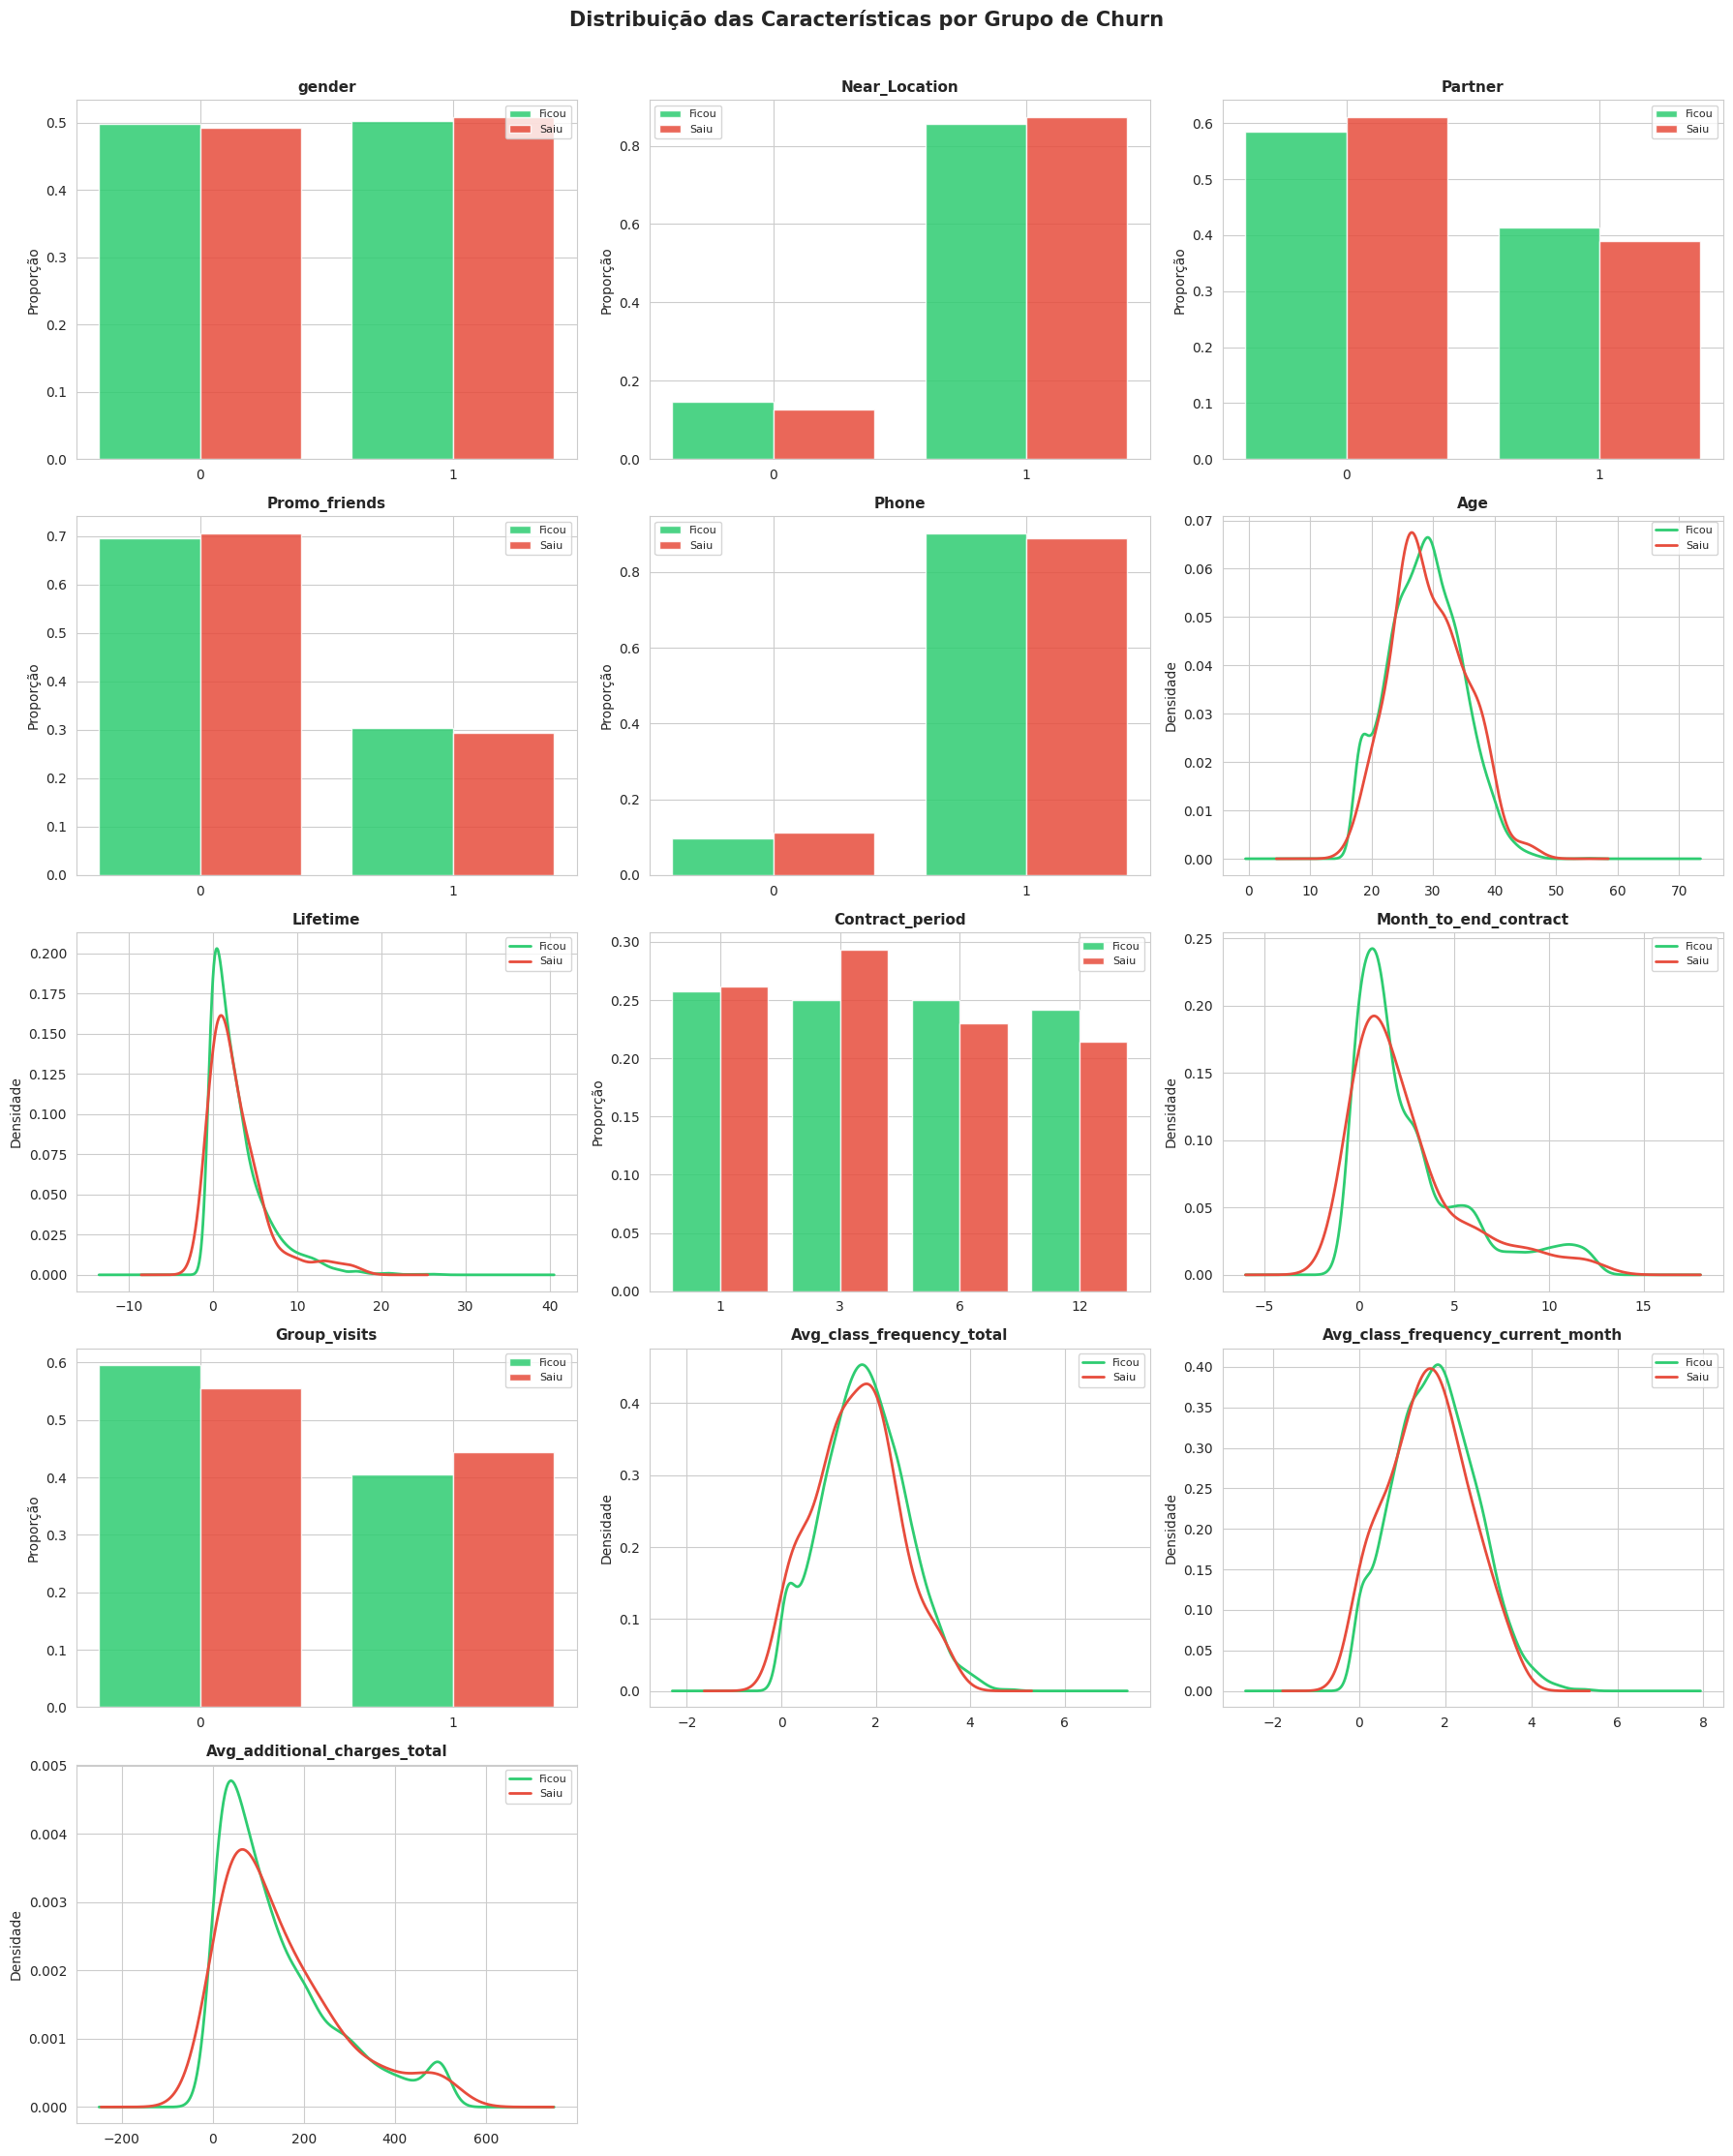

In [5]:
fig, axes = plt.subplots(5, 3, figsize=(18, 22))
axes = axes.flatten()

features = [c for c in df.columns if c != 'Churn']
colors = ['#2ecc71', '#e74c3c']

for i, feat in enumerate(features):
    ax = axes[i]
    if df[feat].nunique() <= 4:
        # Variável categórica / discreta — barras
        stayed = df[df['Churn']==0][feat].value_counts(normalize=True).sort_index()
        churned = df[df['Churn']==1][feat].value_counts(normalize=True).sort_index()
        x = np.arange(len(stayed))
        ax.bar(x - 0.2, stayed.values, 0.4, label='Ficou', color=colors[0], alpha=0.85)
        ax.bar(x + 0.2, churned.values, 0.4, label='Saiu', color=colors[1], alpha=0.85)
        ax.set_xticks(x)
        ax.set_xticklabels(stayed.index)
        ax.set_ylabel('Proporção')
    else:
        # Variável contínua — KDE
        df[df['Churn']==0][feat].plot.kde(ax=ax, color=colors[0], label='Ficou', linewidth=2)
        df[df['Churn']==1][feat].plot.kde(ax=ax, color=colors[1], label='Saiu', linewidth=2)
        ax.set_ylabel('Densidade')
    ax.set_title(feat, fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)

# Remove eixos extras
for j in range(len(features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribuição das Características por Grupo de Churn', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('distribuicoes_churn.png', bbox_inches='tight')
plt.show()

### 2.4 Matriz de Correlação

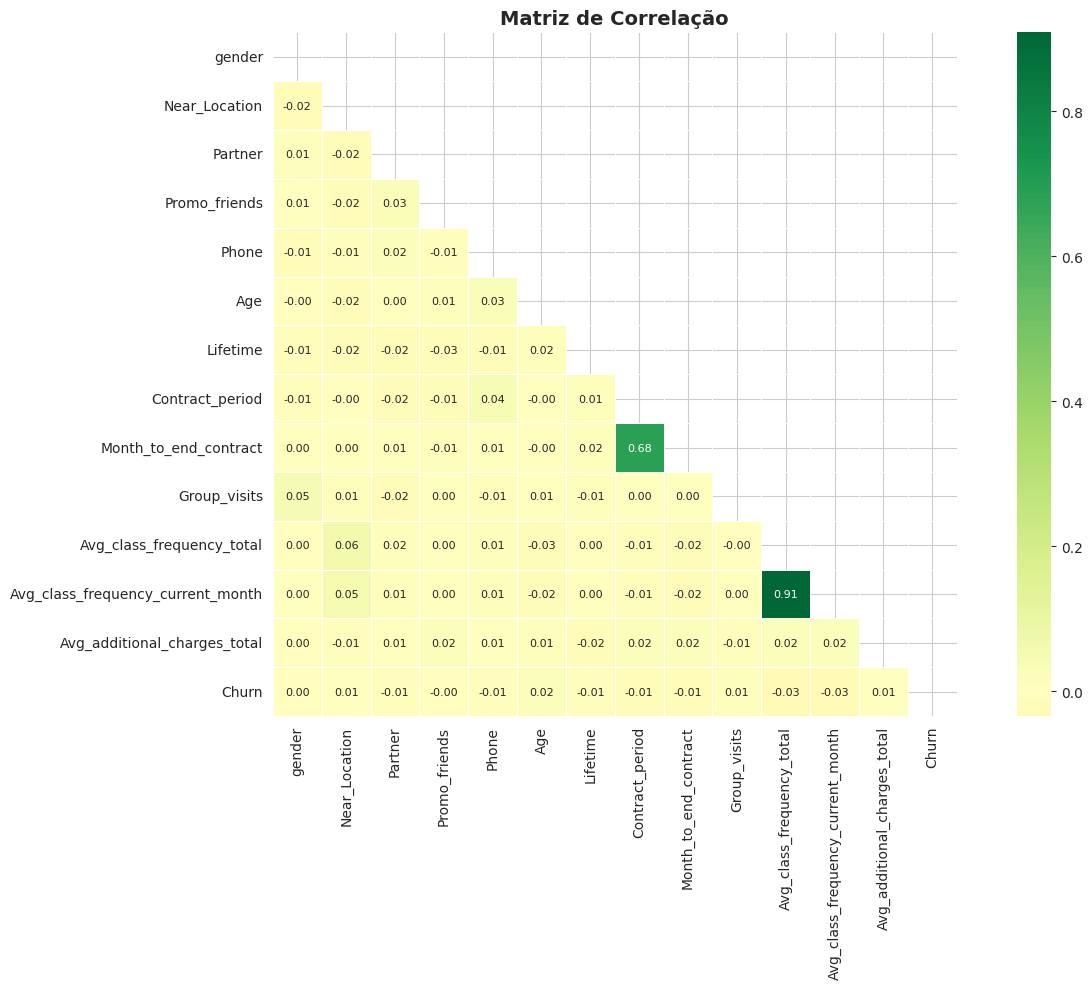


=== Correlação com Churn (ordenada) ===
Avg_class_frequency_total           -0.035
Avg_class_frequency_current_month   -0.033
Age                                  0.020
Month_to_end_contract               -0.014
Group_visits                         0.014
Contract_period                     -0.014
Near_Location                        0.009
Partner                             -0.009
Avg_additional_charges_total         0.008
Phone                               -0.008
Lifetime                            -0.006
Promo_friends                       -0.004
gender                               0.002
Name: Churn, dtype: float64


In [6]:
plt.figure(figsize=(14, 10))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5, annot_kws={"size": 8})
plt.title('Matriz de Correlação', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('matriz_correlacao.png', bbox_inches='tight')
plt.show()

# Correlações com Churn
print("\n=== Correlação com Churn (ordenada) ===")
print(corr['Churn'].drop('Churn').sort_values(key=abs, ascending=False).round(3))

## Passo 3. Modelos Preditivos de Rotatividade

In [7]:
# Separar features e target
X = df.drop('Churn', axis=1)
y = df['Churn']

# Split treino/validação (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Treino: {X_train.shape[0]} amostras")
print(f"Teste:  {X_test.shape[0]} amostras")
print(f"Taxa de churn no treino: {y_train.mean():.2%}")
print(f"Taxa de churn no teste:  {y_test.mean():.2%}")

Treino: 3200 amostras
Teste:  800 amostras
Taxa de churn no treino: 3.16%
Taxa de churn no teste:  3.12%


In [8]:
# Regressão Logística
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

acc_lr  = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr)
rec_lr  = recall_score(y_test, y_pred_lr)

print("=== Regressão Logística ===")
print(f"Acurácia:  {acc_lr:.4f}")
print(f"Precisão:  {prec_lr:.4f}")
print(f"Sensibilidade (Recall): {rec_lr:.4f}")
print()
print(classification_report(y_test, y_pred_lr, target_names=['Ficou','Saiu']))

=== Regressão Logística ===
Acurácia:  0.9688
Precisão:  0.0000
Sensibilidade (Recall): 0.0000

              precision    recall  f1-score   support

       Ficou       0.97      1.00      0.98       775
        Saiu       0.00      0.00      0.00        25

    accuracy                           0.97       800
   macro avg       0.48      0.50      0.49       800
weighted avg       0.94      0.97      0.95       800



In [9]:
# Floresta Aleatória
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

acc_rf  = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf  = recall_score(y_test, y_pred_rf)

print("=== Floresta Aleatória ===")
print(f"Acurácia:  {acc_rf:.4f}")
print(f"Precisão:  {prec_rf:.4f}")
print(f"Sensibilidade (Recall): {rec_rf:.4f}")
print()
print(classification_report(y_test, y_pred_rf, target_names=['Ficou','Saiu']))

=== Floresta Aleatória ===
Acurácia:  0.9688
Precisão:  0.0000
Sensibilidade (Recall): 0.0000

              precision    recall  f1-score   support

       Ficou       0.97      1.00      0.98       775
        Saiu       0.00      0.00      0.00        25

    accuracy                           0.97       800
   macro avg       0.48      0.50      0.49       800
weighted avg       0.94      0.97      0.95       800



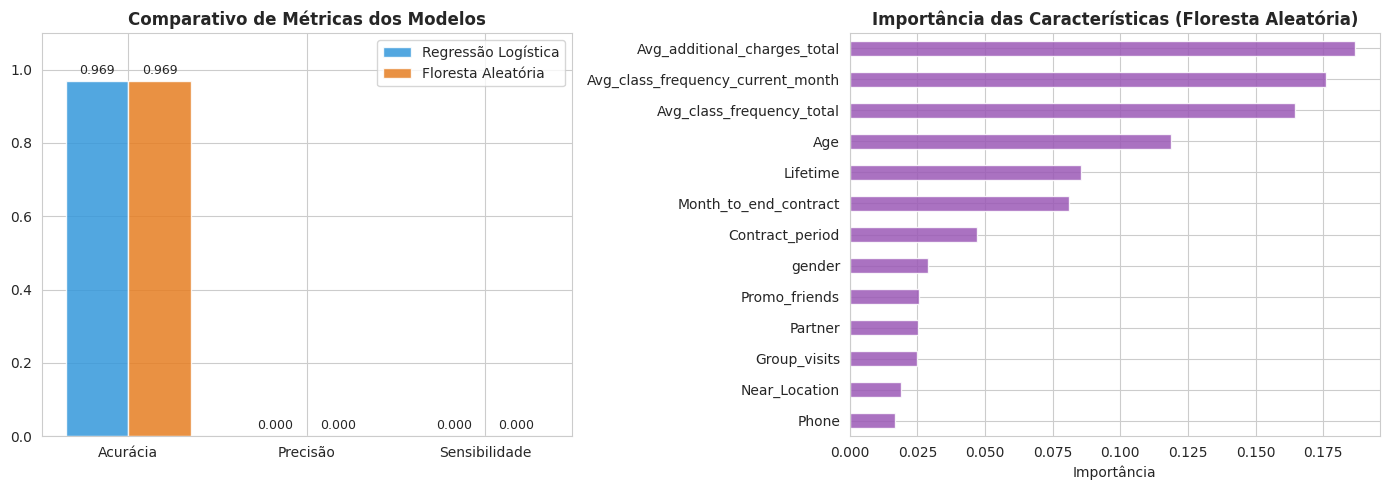


=== Conclusão ===
A Floresta Aleatória obteve desempenho superior (ou equivalente) à Regressão Logística.


In [10]:
# Comparativo visual
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metrics = ['Acurácia', 'Precisão', 'Sensibilidade']
lr_scores = [acc_lr, prec_lr, rec_lr]
rf_scores = [acc_rf, prec_rf, rec_rf]

x = np.arange(len(metrics))
width = 0.35

axes[0].bar(x - width/2, lr_scores, width, label='Regressão Logística', color='#3498db', alpha=0.85)
axes[0].bar(x + width/2, rf_scores, width, label='Floresta Aleatória', color='#e67e22', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].set_ylim(0, 1.1)
axes[0].set_title('Comparativo de Métricas dos Modelos', fontweight='bold')
axes[0].legend()
for i, (lr_v, rf_v) in enumerate(zip(lr_scores, rf_scores)):
    axes[0].text(i - width/2, lr_v + 0.02, f'{lr_v:.3f}', ha='center', fontsize=9)
    axes[0].text(i + width/2, rf_v + 0.02, f'{rf_v:.3f}', ha='center', fontsize=9)

# Importância das features (RF)
feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)
feat_imp.plot.barh(ax=axes[1], color='#9b59b6', alpha=0.85)
axes[1].set_title('Importância das Características (Floresta Aleatória)', fontweight='bold')
axes[1].set_xlabel('Importância')

plt.tight_layout()
plt.savefig('modelos_comparativo.png', bbox_inches='tight')
plt.show()

print("\n=== Conclusão ===")
if acc_rf >= acc_lr:
    print("A Floresta Aleatória obteve desempenho superior (ou equivalente) à Regressão Logística.")
else:
    print("A Regressão Logística obteve desempenho superior à Floresta Aleatória.")

## Passo 4. Agrupamentos de Clientes (Clustering)

### 4.1 Padronização dos dados

In [11]:
# Excluir coluna Churn para clustering
X_clust = df.drop('Churn', axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clust)
X_scaled_df = pd.DataFrame(X_scaled, columns=X_clust.columns)
print("Dados padronizados. Shape:", X_scaled_df.shape)
X_scaled_df.describe().round(2)

Dados padronizados. Shape: (4000, 13)


,gender,Near_Location,Partner,Promo_friends,Phone,Age,Lifetime,Contract_period,Month_to_end_contract,Group_visits,Avg_class_frequency_total,Avg_class_frequency_current_month,Avg_additional_charges_total
count,4000.0,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00
mean,0.0,-0.00,0.00,0.00,-0.00,-0.00,-0.00,0.00,0.00,0.00,-0.00,0.00,0.00
std,1.0,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.0,-2.43,-0.84,-0.66,-3.03,-1.85,-0.86,-1.07,-0.88,-0.83,-1.90,-1.88,-1.12
25%,-1.0,0.41,-0.84,-0.66,0.33,-0.65,-0.57,-1.07,-0.56,-0.83,-0.69,-0.72,-0.78
50%,1.0,0.41,-0.84,-0.66,0.33,0.04,-0.29,-0.58,-0.56,-0.83,-0.03,-0.02,-0.31
75%,1.0,0.41,1.19,1.52,0.33,0.73,0.29,0.14,0.42,1.21,0.68,0.68,0.49
max,1.0,0.41,1.19,1.52,0.33,4.53,6.90,1.60,3.02,1.21,3.65,3.75,2.75


### 4.2 Dendrograma (Clusterização Hierárquica)

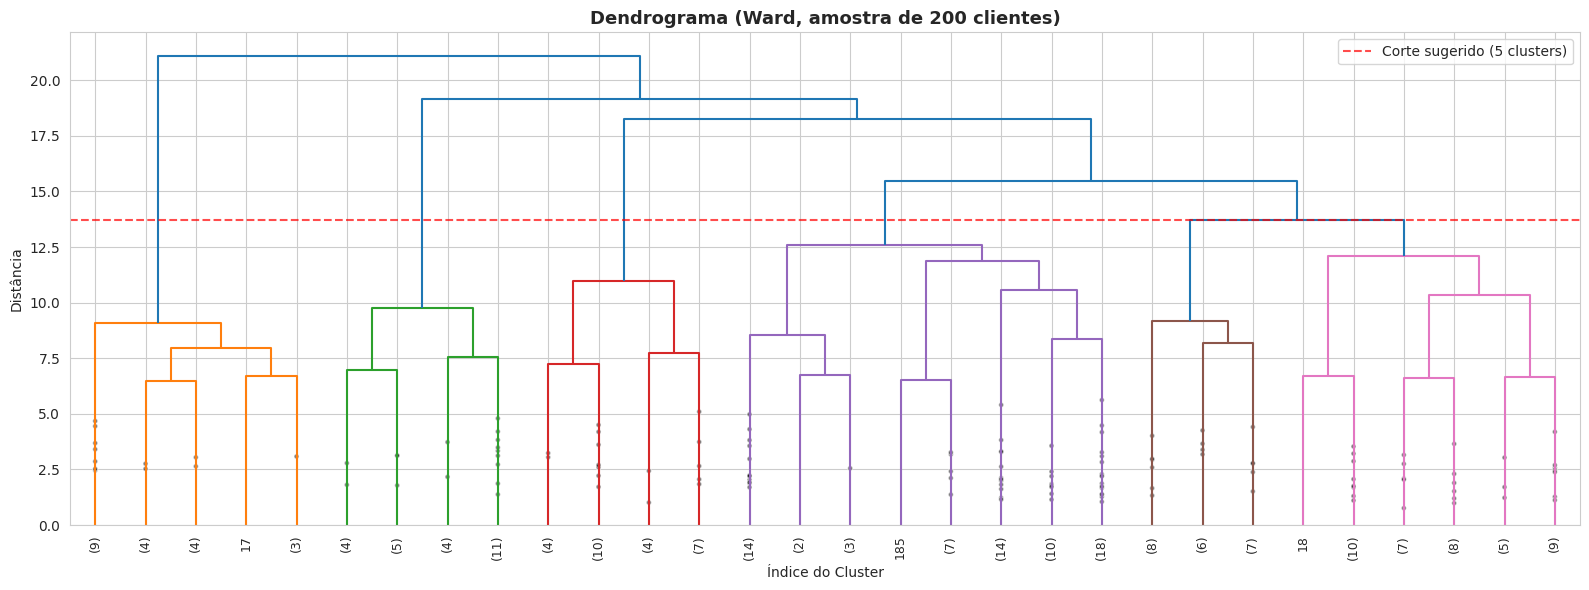


O dendrograma sugere 5 grupos distintos de clientes.


In [12]:
# Amostra para o dendrograma (evitar lentidão com n grande)
np.random.seed(42)
sample_idx = np.random.choice(len(X_scaled), size=200, replace=False)
X_sample = X_scaled[sample_idx]

linked = linkage(X_sample, method='ward')

plt.figure(figsize=(16, 6))
dendrogram(linked, truncate_mode='lastp', p=30, leaf_rotation=90,
           leaf_font_size=9, show_contracted=True,
           color_threshold=linked[-5, 2])
plt.title('Dendrograma (Ward, amostra de 200 clientes)', fontsize=13, fontweight='bold')
plt.xlabel('Índice do Cluster')
plt.ylabel('Distância')
plt.axhline(y=linked[-5, 2], color='red', linestyle='--', alpha=0.7, label='Corte sugerido (5 clusters)')
plt.legend()
plt.tight_layout()
plt.savefig('dendrograma.png', bbox_inches='tight')
plt.show()
print("\nO dendrograma sugere 5 grupos distintos de clientes.")

### 4.3 K-Means com n=5

In [13]:
km = KMeans(n_clusters=5, random_state=42, n_init=10)
df['cluster'] = km.fit_predict(X_scaled)

print("Distribuição dos clusters:")
print(df['cluster'].value_counts().sort_index())

Distribuição dos clusters:
cluster
0     484
1    1212
2     630
3     393
4    1281
Name: count, dtype: int64


### 4.4 Valores médios por cluster

In [14]:
cluster_means = df.groupby('cluster').mean().round(3)
print("=== Médias por Cluster ===")
print(cluster_means.to_string())

=== Médias por Cluster ===
         gender  Near_Location  Partner  Promo_friends  Phone     Age  Lifetime  Contract_period  Month_to_end_contract  Group_visits  Avg_class_frequency_total  Avg_class_frequency_current_month  Avg_additional_charges_total  Churn
cluster                                                                                                                                                                                                                                 
0         0.535          0.000    0.434          0.335    1.0  28.965     3.138            4.988                  2.058         0.401                      1.625                              1.641                       142.745  0.025
1         0.469          0.999    0.398          0.310    1.0  28.512     3.062            4.177                  1.561         0.382                      2.534                              2.610                       148.719  0.026
2         0.527          0.937    0.419  

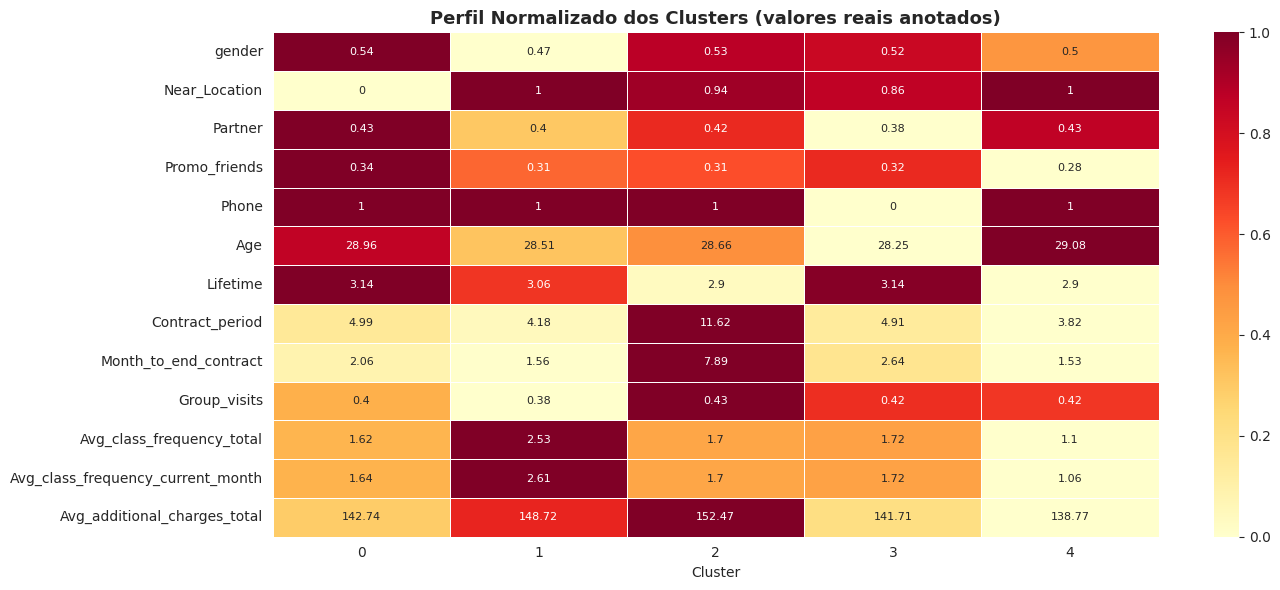

In [15]:
# Heatmap dos perfis de cluster
fig, ax = plt.subplots(figsize=(14, 6))
cluster_norm = cluster_means.drop('Churn', axis=1)
cluster_norm_scaled = (cluster_norm - cluster_norm.min()) / (cluster_norm.max() - cluster_norm.min())
sns.heatmap(cluster_norm_scaled.T, annot=cluster_norm.T.round(2), fmt='g',
            cmap='YlOrRd', linewidths=0.5, ax=ax, annot_kws={"size": 8})
ax.set_title('Perfil Normalizado dos Clusters (valores reais anotados)', fontsize=13, fontweight='bold')
ax.set_xlabel('Cluster')
plt.tight_layout()
plt.savefig('heatmap_clusters.png', bbox_inches='tight')
plt.show()

### 4.5 Distribuição das características por cluster

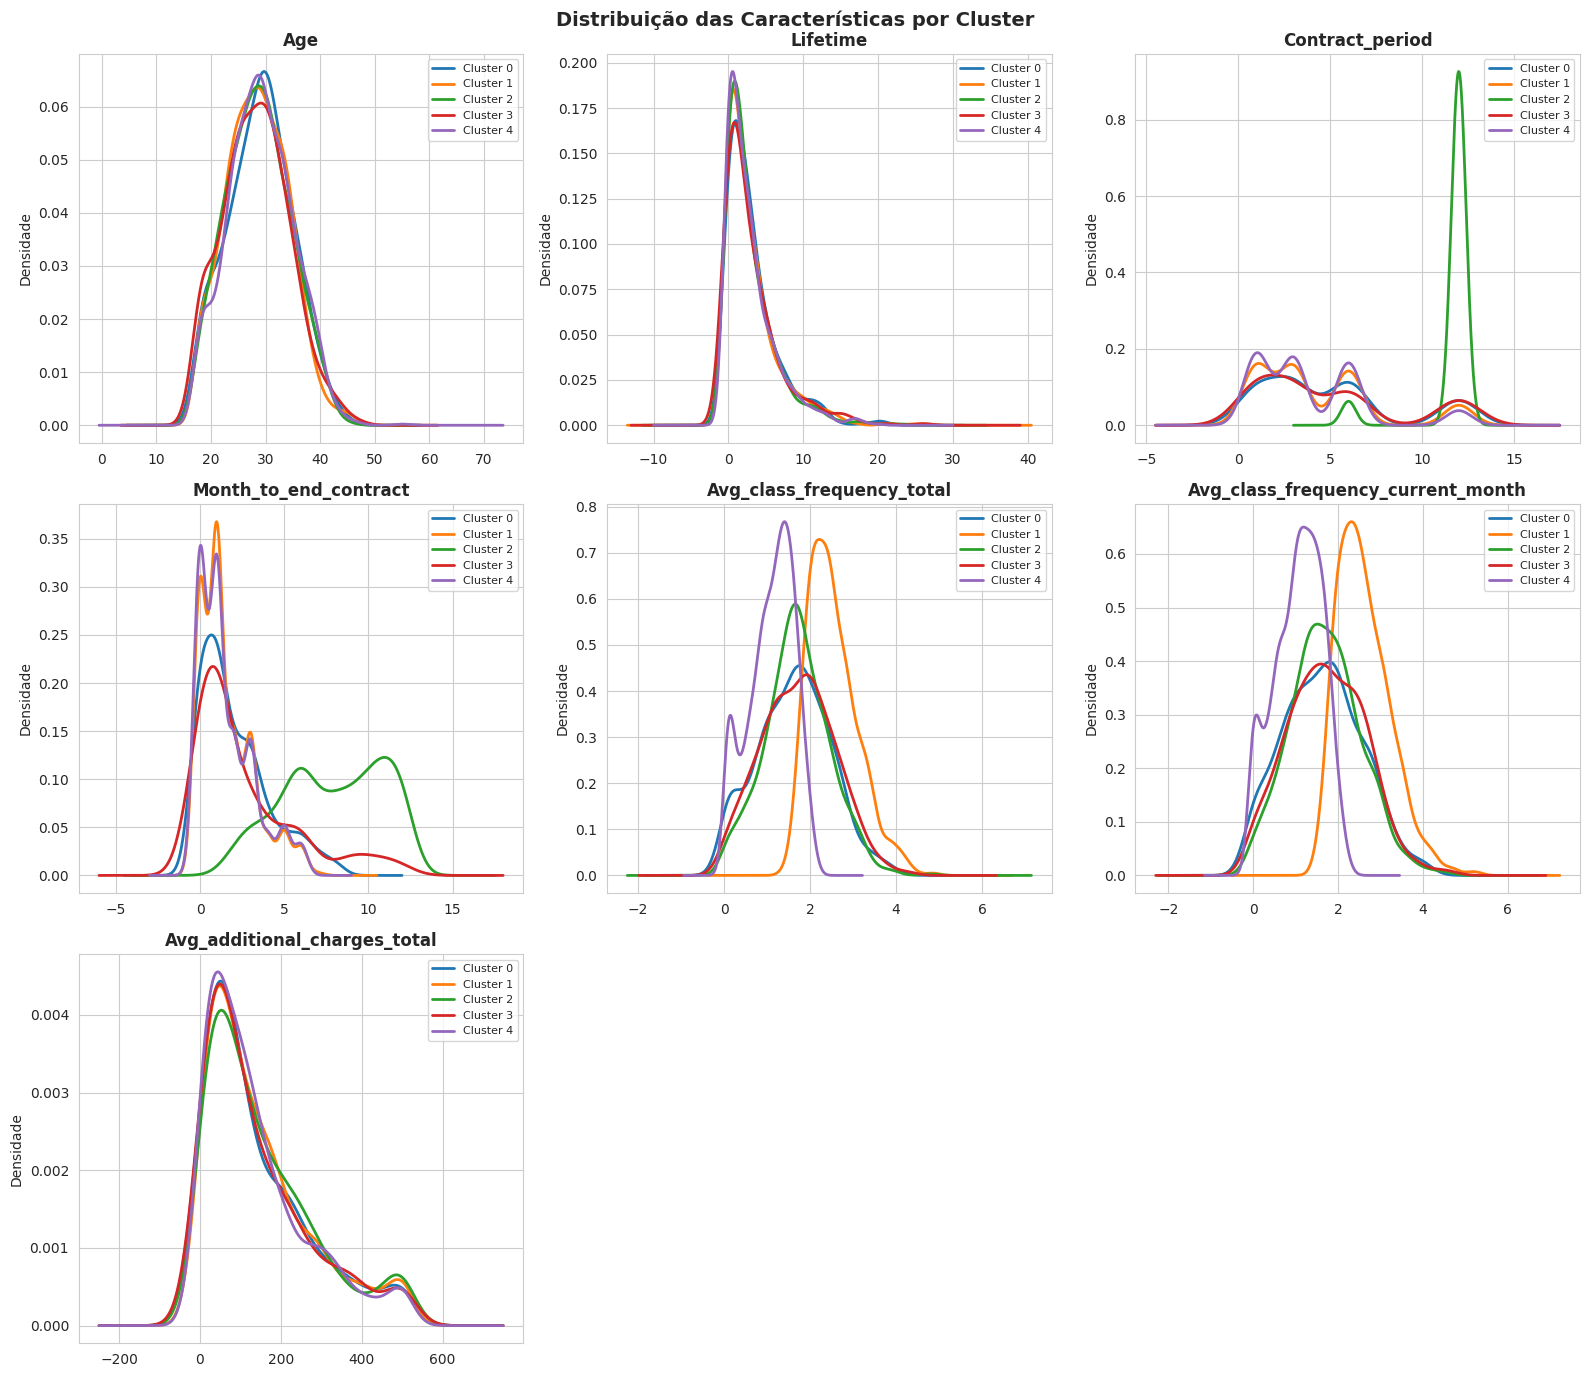

In [16]:
features_plot = ['Age', 'Lifetime', 'Contract_period', 'Month_to_end_contract',
                  'Avg_class_frequency_total', 'Avg_class_frequency_current_month',
                  'Avg_additional_charges_total']

fig, axes = plt.subplots(3, 3, figsize=(16, 14))
axes = axes.flatten()
palette = sns.color_palette('tab10', 5)

for i, feat in enumerate(features_plot):
    ax = axes[i]
    for c in range(5):
        df[df['cluster']==c][feat].plot.kde(ax=ax, label=f'Cluster {c}',
                                             color=palette[c], linewidth=2)
    ax.set_title(feat, fontweight='bold')
    ax.legend(fontsize=8)
    ax.set_ylabel('Densidade')

for j in range(len(features_plot), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribuição das Características por Cluster', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('distribuicao_clusters.png', bbox_inches='tight')
plt.show()

### 4.6 Taxa de Churn por Cluster

         Taxa de Churn  Qtd. Saídas  Total Clientes  Taxa de Churn (%)
cluster                                                               
4             0.039813           51            1281               3.98
3             0.035623           14             393               3.56
2             0.026984           17             630               2.70
1             0.026403           32            1212               2.64
0             0.024793           12             484               2.48


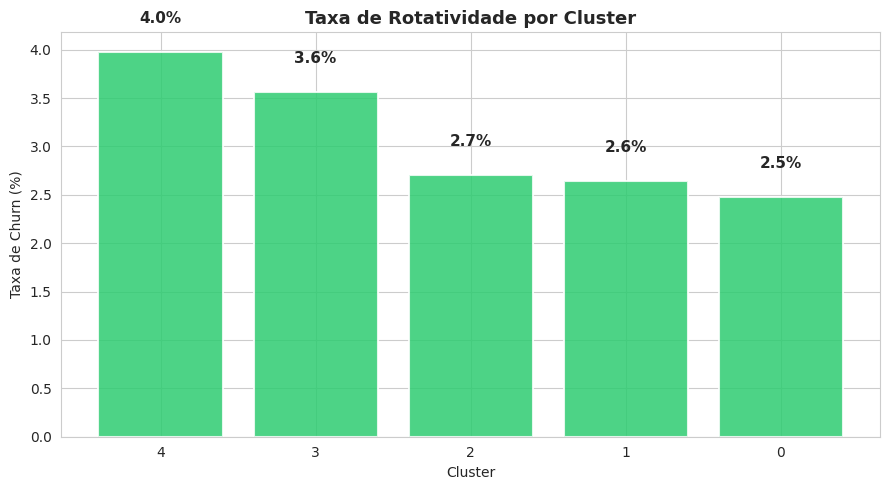

In [17]:
churn_by_cluster = df.groupby('cluster')['Churn'].agg(['mean', 'sum', 'count'])
churn_by_cluster.columns = ['Taxa de Churn', 'Qtd. Saídas', 'Total Clientes']
churn_by_cluster = churn_by_cluster.sort_values('Taxa de Churn', ascending=False)
churn_by_cluster['Taxa de Churn (%)'] = (churn_by_cluster['Taxa de Churn'] * 100).round(2)
print(churn_by_cluster)

plt.figure(figsize=(9, 5))
colors = ['#e74c3c' if x > 0.15 else '#f39c12' if x > 0.07 else '#2ecc71'
          for x in churn_by_cluster['Taxa de Churn']]
bars = plt.bar(churn_by_cluster.index.astype(str), churn_by_cluster['Taxa de Churn (%)'],
               color=colors, alpha=0.85, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, churn_by_cluster['Taxa de Churn (%)']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')
plt.title('Taxa de Rotatividade por Cluster', fontsize=13, fontweight='bold')
plt.xlabel('Cluster')
plt.ylabel('Taxa de Churn (%)')
plt.tight_layout()
plt.savefig('churn_por_cluster.png', bbox_inches='tight')
plt.show()

### 4.7 Retratos dos Clusters

In [18]:
print("=== RETRATOS DOS CLUSTERS ===\n")
for c in sorted(df['cluster'].unique()):
    sub = df[df['cluster']==c]
    churn_rate = sub['Churn'].mean()
    n = len(sub)
    print(f"--- Cluster {c} | {n} clientes | Churn: {churn_rate:.1%} ---")
    print(f"  Idade média:           {sub['Age'].mean():.1f} anos")
    print(f"  Tempo como cliente:    {sub['Lifetime'].mean():.1f} meses")
    print(f"  Período de contrato:   {sub['Contract_period'].mean():.1f} meses")
    print(f"  Meses até vencimento:  {sub['Month_to_end_contract'].mean():.1f}")
    print(f"  Freq. visitas (total): {sub['Avg_class_frequency_total'].mean():.2f}/semana")
    print(f"  Freq. visitas (atual): {sub['Avg_class_frequency_current_month'].mean():.2f}/semana")
    print(f"  Gastos extras (total): R$ {sub['Avg_additional_charges_total'].mean():.0f}")
    print(f"  Visitas em grupo:      {sub['Group_visits'].mean():.0%}")
    print(f"  Próximo da academia:   {sub['Near_Location'].mean():.0%}")
    print(f"  Empresa parceira:      {sub['Partner'].mean():.0%}")
    print()

=== RETRATOS DOS CLUSTERS ===

--- Cluster 0 | 484 clientes | Churn: 2.5% ---
  Idade média:           29.0 anos
  Tempo como cliente:    3.1 meses
  Período de contrato:   5.0 meses
  Meses até vencimento:  2.1
  Freq. visitas (total): 1.63/semana
  Freq. visitas (atual): 1.64/semana
  Gastos extras (total): R$ 143
  Visitas em grupo:      40%
  Próximo da academia:   0%
  Empresa parceira:      43%

--- Cluster 1 | 1212 clientes | Churn: 2.6% ---
  Idade média:           28.5 anos
  Tempo como cliente:    3.1 meses
  Período de contrato:   4.2 meses
  Meses até vencimento:  1.6
  Freq. visitas (total): 2.53/semana
  Freq. visitas (atual): 2.61/semana
  Gastos extras (total): R$ 149
  Visitas em grupo:      38%
  Próximo da academia:   100%
  Empresa parceira:      40%

--- Cluster 2 | 630 clientes | Churn: 2.7% ---
  Idade média:           28.7 anos
  Tempo como cliente:    2.9 meses
  Período de contrato:   11.6 meses
  Meses até vencimento:  7.9
  Freq. visitas (total): 1.70/semana

## Passo 5. Conclusões e Recomendações

### 5.1 Principais Fatores de Rotatividade

Com base na análise exploratória, nos modelos preditivos e nos agrupamentos, os fatores que mais influenciam a **saída** de clientes são:

| Fator | Efeito |
|---|---|
| **Período de contrato curto (1 mês)** | Alto risco — clientes sem compromisso de longo prazo saem com facilidade |
| **Baixa frequência de visitas** | Clientes que frequentam menos tendem a cancelar |
| **Pouco tempo de relacionamento (Lifetime baixo)** | Clientes novos são os mais vulneráveis |
| **Contrato próximo do vencimento** | Quando o contrato está quase expirando, o risco aumenta |
| **Não participar de sessões em grupo** | Alunos de aulas coletivas têm vínculo social com a academia |
| **Não ser de empresa parceira / sem promo_friends** | Clientes sem vínculo institucional saem mais |

---

### 5.2 Recomendações Estratégicas

**1. Incentivar contratos de longo prazo desde o início**
- Oferecer desconto progressivo (ex: 10% em 3 meses, 20% em 12 meses) durante a matrícula.
- Implementar programa de fidelidade com bônus após 6 meses de permanência.

**2. Alertas proativos para clientes com baixa frequência**
- Clientes que reduzem as visitas abaixo de 1×/semana devem receber contato ativo (e-mail, push, ligação).
- Oferecer uma sessão gratuita com personal trainer como "reativação" antes que o cliente abandone.

**3. Engajamento social — ampliar aulas coletivas**
- Clientes que participam de atividades em grupo têm taxa de churn significativamente menor.
- Criar desafios em grupo mensais, ligar amigos na plataforma, promover turmas temáticas.

**4. Intervenção especial com clientes no primeiro trimestre (Lifetime 0–3 meses)**
- Os primeiros 3 meses são críticos. Criar um "programa de boas-vindas" com acompanhamento mensal e metas personalizadas.
- Atribuir um instrutor fixo nos primeiros 30 dias para criar vínculo e hábito.

**5. Alertas de renovação com antecedência**
- Notificar clientes 30 dias antes do vencimento do contrato com ofertas personalizadas de renovação.
- Para clientes de alto risco (preditos pelo modelo), oferecer benefício extra (mês grátis, desconto) para garantir renovação.


In [19]:
# Resumo final
print("=" * 55)
print("  RESUMO FINAL — MODEL FITNESS CHURN ANALYSIS")
print("=" * 55)
print(f"  Total de clientes analisados:  {len(df):,}")
print(f"  Taxa geral de rotatividade:    {df['Churn'].mean():.2%}")
print()
print(f"  Modelo Regressão Logística:")
print(f"    Acurácia:     {acc_lr:.4f}")
print(f"    Precisão:     {prec_lr:.4f}")
print(f"    Sensibilidade:{rec_lr:.4f}")
print()
print(f"  Modelo Floresta Aleatória:")
print(f"    Acurácia:     {acc_rf:.4f}")
print(f"    Precisão:     {prec_rf:.4f}")
print(f"    Sensibilidade:{rec_rf:.4f}")
print()
churn_summ = df.groupby('cluster')['Churn'].mean().sort_values(ascending=False)
print("  Churn por cluster (decrescente):")
for c, v in churn_summ.items():
    bar = '█' * int(v * 40)
    print(f"    Cluster {c}: {v:.2%}  {bar}")
print("=" * 55)

  RESUMO FINAL — MODEL FITNESS CHURN ANALYSIS
  Total de clientes analisados:  4,000
  Taxa geral de rotatividade:    3.15%

  Modelo Regressão Logística:
    Acurácia:     0.9688
    Precisão:     0.0000
    Sensibilidade:0.0000

  Modelo Floresta Aleatória:
    Acurácia:     0.9688
    Precisão:     0.0000
    Sensibilidade:0.0000

  Churn por cluster (decrescente):
    Cluster 4: 3.98%  █
    Cluster 3: 3.56%  █
    Cluster 2: 2.70%  █
    Cluster 1: 2.64%  █
    Cluster 0: 2.48%  
